In [17]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from pathlib import Path

In [18]:
def read_hdf5_file(file_path):
    with h5py.File(file_path, "r") as f:
        return f["image"][:], f["mask"][:]

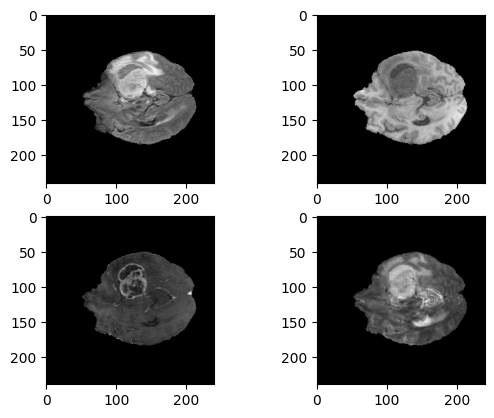

In [70]:
# Plot the four MRI channels of a slice
im, mask = read_hdf5_file(
    "../../data/BraTS2020_training_data/content/data/volume_1_slice_60.h5"
)

fig, axs = plt.subplots(2, 2)
axs[0, 0].imshow(im[:, :, 0], cmap="gray")
axs[0, 1].imshow(im[:, :, 1], cmap="gray")
axs[1, 0].imshow(im[:, :, 2], cmap="gray")
axs[1, 1].imshow(im[:, :, 3], cmap="gray")

plt.show()

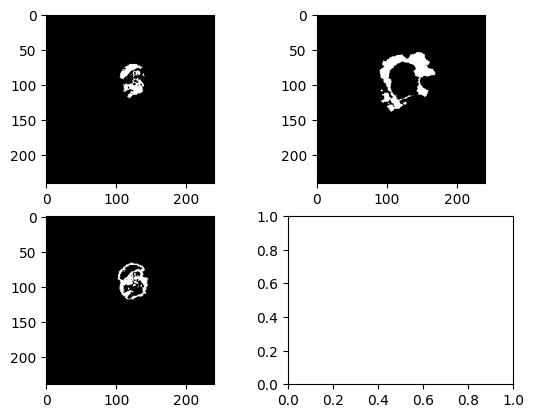

In [ ]:
# Plot the 3 mask channels separately
fig, axs = plt.subplots(2, 2)
axs[0, 0].imshow(mask[:, :, 0], cmap="gray")
axs[0, 1].imshow(mask[:, :, 1], cmap="gray")
axs[1, 0].imshow(mask[:, :, 2], cmap="gray")

plt.show()

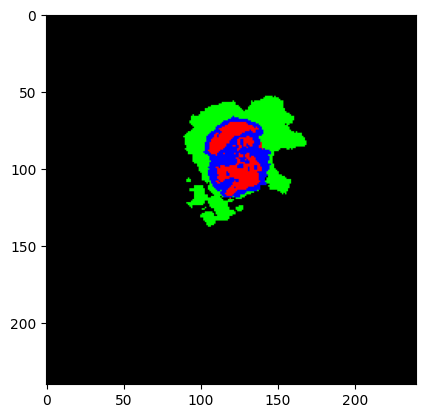

In [ ]:
# Plot the mask channels together
plt.imshow(mask * 255)
plt.show()

In [ ]:
metadata = pd.read_csv("../../data/BraTS20 Training Metadata.csv")
print("Total number of brain scans:", metadata["volume"].nunique())
print(
    "Number of slices with a tumor:",
    metadata[metadata["target"] == 1].shape[0],
)
print(
    "Number of slices without a tumor:",
    metadata[metadata["target"] == 0].shape[0],
)
print("Total number of slices:", metadata.shape[0])

Total number of brain scans: 369
Number of slices with a tumor: 24422
Number of slices without a tumor: 32773
Total number of slices: 57195


In [91]:
(metadata[["volume", "target"]].groupby("volume")["target"].max() == 0).any()

np.False_

(array([40174.,  4963.,  4016.,  3396.,  2148.,  1405.,   689.,   293.,
           57.,    54.]),
 array([0.       , 0.0111875, 0.022375 , 0.0335625, 0.04475  , 0.0559375,
        0.067125 , 0.0783125, 0.0895   , 0.1006875, 0.111875 ]),
 <BarContainer object of 10 artists>)

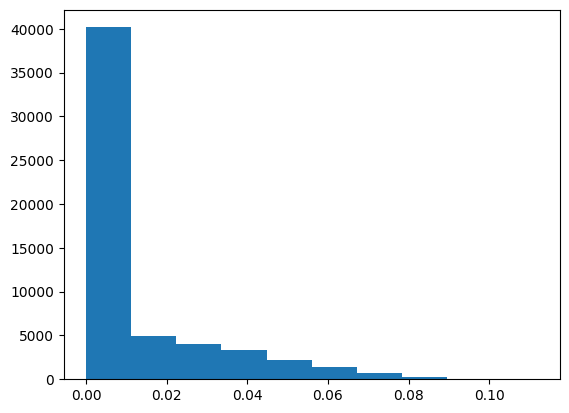

In [94]:
plt.hist(1 - metadata["background_ratio"])

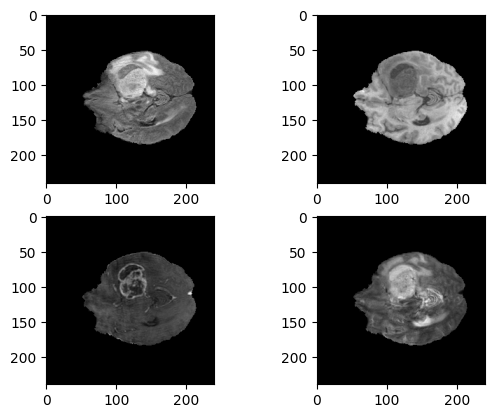

In [35]:
import sys
from pathlib import Path

# Add parent directory to path so we can import data module
sys.path.insert(0, str(Path(".").resolve().parent))

from data.data_loading import load_metadata, BRATSDataset, DATA_PATH

md = load_metadata("../.." /DATA_PATH / "content/data/meta_data.csv")
ds = BRATSDataset(md)

im_norm = ds[9515]["image"]
fig, axs = plt.subplots(2, 2)
axs[0, 0].imshow(im[:, :, 0], cmap="gray")
axs[0, 1].imshow(im[:, :, 1], cmap="gray")
axs[1, 0].imshow(im[:, :, 2], cmap="gray")
axs[1, 1].imshow(im[:, :, 3], cmap="gray")

plt.show()

In [ ]:
# Test how background pixels are normalized
im_norm = ds[615]["image"]
slice = im_norm[:1, :10, 0]
print(slice)
im_norm = ds[515]["image"]
slice = im_norm[:1, :10, 0]
print(slice)
im_norm = ds[115]["image"]
slice = im_norm[:1, :10, 0]
print(slice)
im_norm = ds[1000]["image"]
slice = im_norm[:1, :10, 0]
print(slice)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[-5.090835 -5.090835 -5.090835 -5.090835 -5.090835 -5.090835 -5.090835
  -5.090835 -5.090835 -5.090835]]
[[-3.3840148 -3.3840148 -3.3840148 -3.3840148 -3.3840148 -3.3840148
  -3.3840148 -3.3840148 -3.3840148 -3.3840148]]
[[-4.4523926 -4.4523926 -4.4523926 -4.4523926 -4.4523926 -4.4523926
  -4.4523926 -4.4523926 -4.4523926 -4.4523926]]
